<a href="https://colab.research.google.com/github/vodnalasuhas/DAA-CSE-C/blob/main/EXP3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

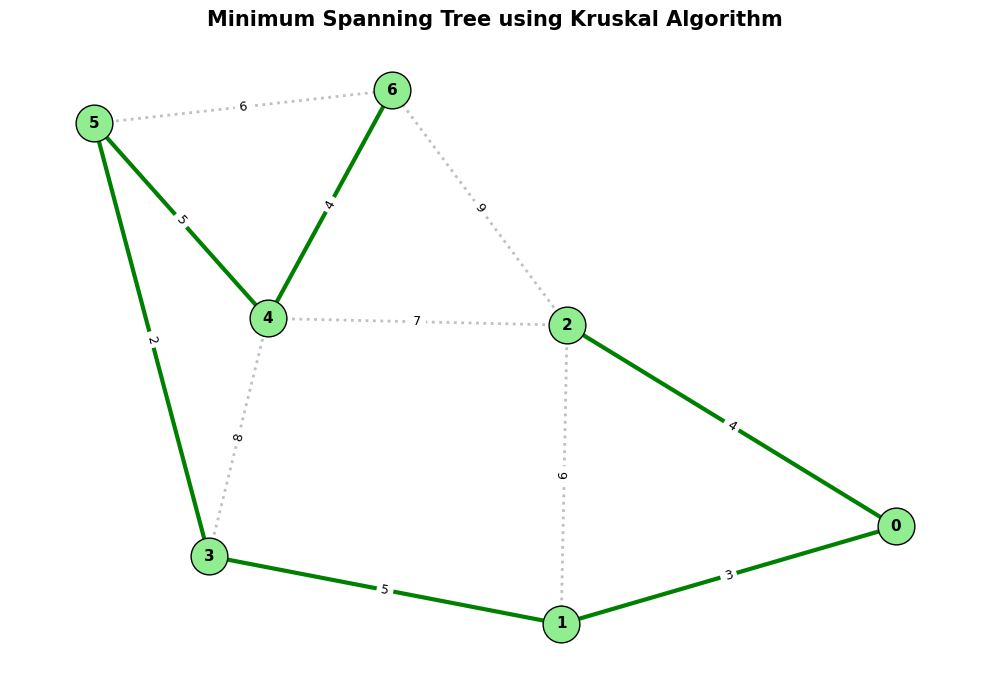

In [4]:
import networkx as nx
import matplotlib.pyplot as plt

# ---------- Union Find ----------

class UnionFind:

    def __init__(self, size):
        self.parent = list(range(size))

    def find(self, vertex):

        while self.parent[vertex] != vertex:
            vertex = self.parent[vertex]

        return vertex

    def union(self, first, second):

        root1 = self.find(first)
        root2 = self.find(second)

        if root1 == root2:
            return False

        self.parent[root2] = root1
        return True


# ---------- Kruskal MST ----------

def kruskal_mst(total_vertices, edges):

    uf = UnionFind(total_vertices)
    mst_edges = []

    ordered_edges = sorted(edges, key=lambda item: item[0])

    for cost, start, end in ordered_edges:

        if uf.union(start, end):
            mst_edges.append((start, end, cost))

        if len(mst_edges) == total_vertices - 1:
            break

    return mst_edges


# ---------- Graph Data ----------

number_of_vertices = 7

edges = [
    (4, 0, 2),
    (3, 0, 1),
    (6, 1, 2),
    (5, 1, 3),
    (7, 2, 4),
    (8, 3, 4),
    (2, 3, 5),
    (5, 4, 5),
    (4, 4, 6),
    (6, 5, 6),
    (9, 2, 6)
]


# ---------- Find MST ----------

mst_result = kruskal_mst(number_of_vertices, edges)


# ---------- Build Network ----------

network = nx.Graph()

for weight, u, v in edges:
    network.add_edge(u, v, weight=weight)


# ---------- Visualization ----------

position = nx.spring_layout(network, seed=10)

plt.figure(figsize=(10, 7))

mst_set = {(min(u, v), max(u, v)) for u, v, w in mst_result}

regular_edges = []
mst_highlight = []

for u, v in network.edges():

    if (min(u, v), max(u, v)) in mst_set:
        mst_highlight.append((u, v))
    else:
        regular_edges.append((u, v))

nx.draw_networkx_edges(
    network,
    position,
    edgelist=regular_edges,
    edge_color="silver",
    style="dotted",
    width=2
)

nx.draw_networkx_edges(
    network,
    position,
    edgelist=mst_highlight,
    edge_color="green",
    width=3
)

nx.draw_networkx_nodes(
    network,
    position,
    node_color="lightgreen",
    node_size=700,
    edgecolors="black"
)

nx.draw_networkx_labels(
    network,
    position,
    font_size=11,
    font_weight="bold"
)

edge_weights = nx.get_edge_attributes(network, "weight")

nx.draw_networkx_edge_labels(
    network,
    position,
    edge_labels=edge_weights,
    font_size=9
)

plt.title(
    "Minimum Spanning Tree using Kruskal Algorithm",
    fontsize=15,
    fontweight="bold"
)

plt.axis("off")
plt.tight_layout()
plt.show()